### **CAR PRICE PREDICTION**

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:


df = pd.read_csv('data/Car_Price_Prediction.csv')
df = df.drop(columns=['Model'])
df.head()

,Make,Year,Engine Size,Mileage,Fuel Type,Transmission,Price
0,Honda,2015,3.9,74176,Petrol,Manual,30246.207931
1,Ford,2014,1.7,94799,Electric,Automatic,22785.747684
2,BMW,2006,4.1,98385,Electric,Manual,25760.290347
3,Honda,2015,2.6,88919,Electric,Automatic,25638.003491
4,Honda,2004,3.4,138482,Petrol,Automatic,21021.386657


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Make          1000 non-null   str    
 1   Year          1000 non-null   int64  
 2   Engine Size   1000 non-null   float64
 3   Mileage       1000 non-null   int64  
 4   Fuel Type     1000 non-null   str    
 5   Transmission  1000 non-null   str    
 6   Price         1000 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 72.9 KB


In [28]:
df.describe()

,Year,Engine Size,Mileage,Price
count,1000.000000,1000.000000,1000.00000,1000.000000
mean,2010.688000,2.798300,97192.48700,25136.615530
std,6.288577,1.024137,59447.31576,5181.401368
min,2000.000000,1.000000,56.00000,6704.953524
25%,2005.000000,1.900000,44768.75000,21587.878370
50%,2011.000000,2.800000,94411.50000,25189.325247
75%,2016.000000,3.700000,148977.75000,28806.368974
max,2021.000000,4.500000,199867.00000,41780.504635


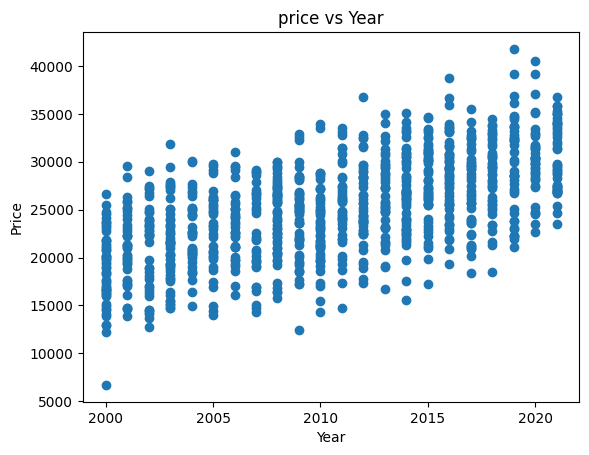

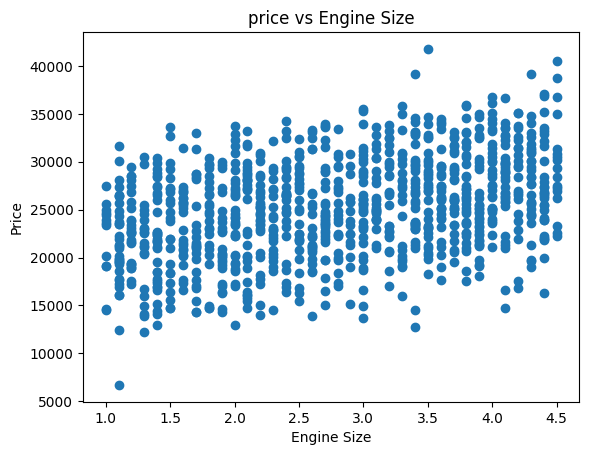

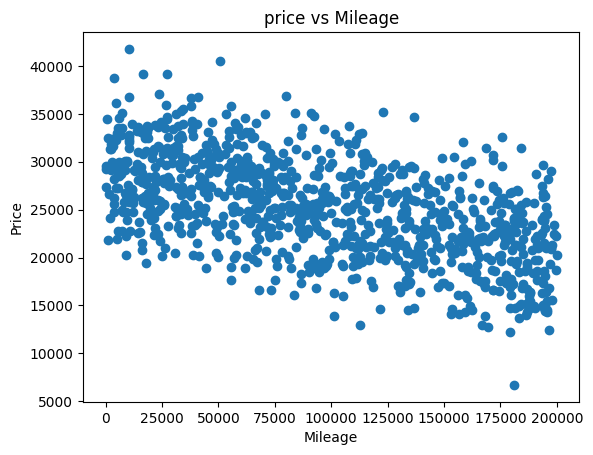

In [29]:
kolom = ['Year', 'Engine Size', 'Mileage']

for col in kolom:
  plt.scatter(df[col], df['Price'])
  plt.xlabel(col)
  plt.ylabel('Price')
  plt.title(f'price vs {col}')
  plt.show()

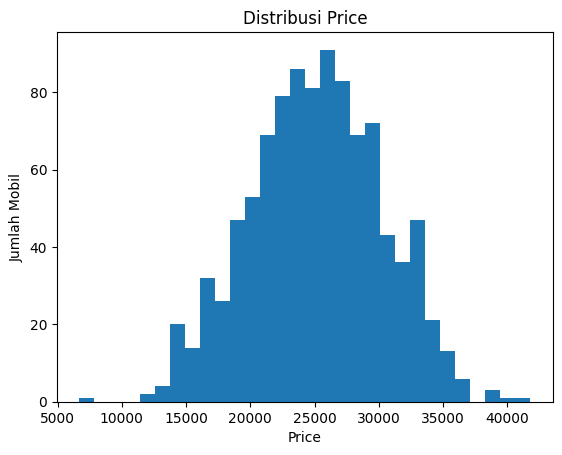

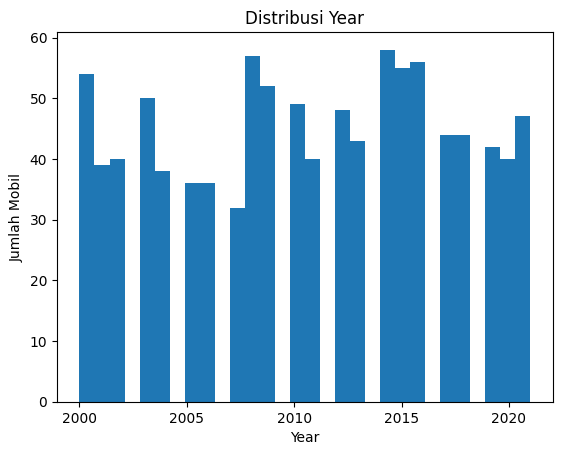

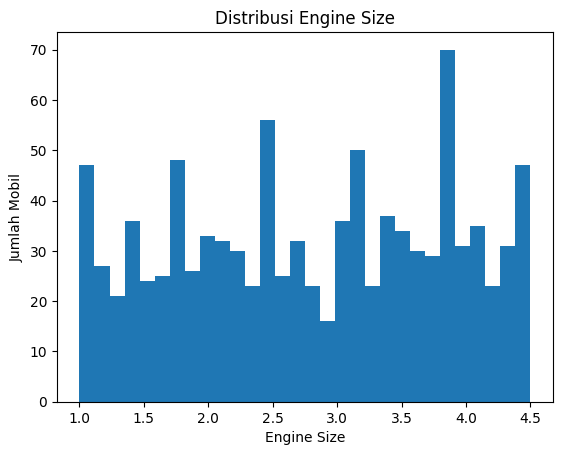

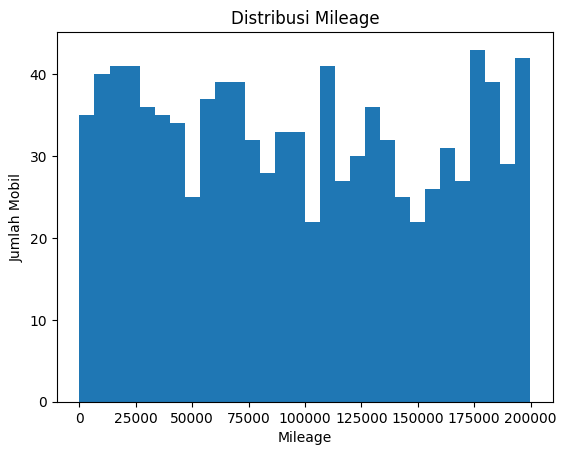

In [30]:
kolom = ['Price', 'Year', 'Engine Size', 'Mileage']

for col in kolom:
  plt.hist(df[col], bins=30)
  plt.xlabel(col)
  plt.ylabel('Jumlah Mobil')
  plt.title(f'Distribusi {col}')
  plt.show()

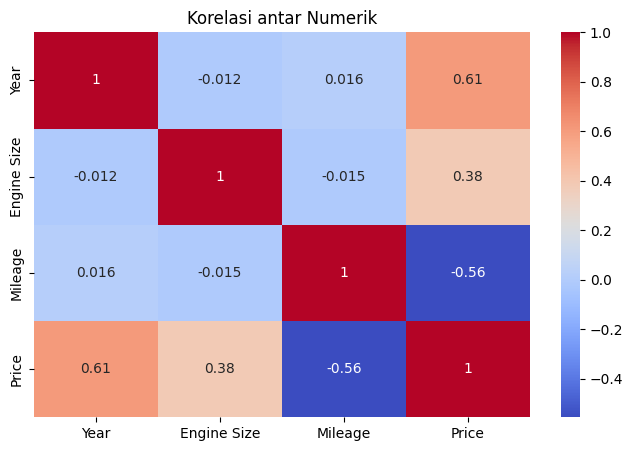

In [31]:
plt.figure(figsize=(8, 5))
sns.heatmap(df.select_dtypes(include='number').corr(),
            annot=True,
            cmap='coolwarm')
plt.title('Korelasi antar Numerik')
plt.show()

In [32]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Price'])
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 6), (200, 6), (800,), (200,))

In [33]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

df.head(3)

,Make,Year,Engine Size,Mileage,Fuel Type,Transmission,Price
0,Honda,2015,3.9,74176,Petrol,Manual,30246.207931
1,Ford,2014,1.7,94799,Electric,Automatic,22785.747684
2,BMW,2006,4.1,98385,Electric,Manual,25760.290347


In [34]:
cat_pipeline = Pipeline([
    ('ohe', OneHotEncoder())
])

In [35]:
preprocessor = ColumnTransformer([
    ('num', 'passthrough', ['Year', 'Engine Size', 'Mileage']),
    ('cat', cat_pipeline, ['Make', 'Fuel Type', 'Transmission'])
])


In [36]:
pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

In [38]:
param_dist = {
    'model__n_estimators' : [100, 200, 300],
    'model__max_depth' : [5, 10, 15, None],
    'model__min_samples_leaf' : [4, 8, 16],
    'model__min_samples_split' : [10, 15, 20]
}

random = RandomizedSearchCV(pipeline, param_dist, n_iter=20, cv=5, scoring='r2', random_state=42, n_jobs=-1)

random.fit(X_train, y_train)
print("Best Params :", random.best_params_)
print("Train R²    :", random.score(X_train, y_train))
print("Test R²     :", random.score(X_test, y_test))

Best Params : {'model__n_estimators': 100, 'model__min_samples_split': 10, 'model__min_samples_leaf': 4, 'model__max_depth': None}
Train R²    : 0.9066437599222958
Test R²     : 0.8042204036599313


In [39]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error

y_pred = random.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

print(f"MAE  : {mae:,.0f}")
print(f"RMSE : {rmse:,.0f}")
print(f"MAPE : {mape:.2f}%")

MAE  : 1,868
RMSE : 2,315
MAPE : 7.98%


In [41]:
import pickle

with open('car_price_predict.pkl', 'wb')as f:
    pickle.dump(random.best_estimator_, f)

with open('car_price_predict.pkl', 'rb')as f:
    model = pickle.load(f)